## **Решение стационарных эллиптических задач на непрямоугольных областях с помощью PINN**


## Подготовка окружения


In [ ]:

import os
import sys
from pathlib import Path

NB_DIR = Path.cwd()
print(f'Рабочая директория: {NB_DIR}')

for f in ('pinn_core.py', 'cell_viz_v4.py'):
    p = NB_DIR / f
    assert p.exists(), (
        f'Не найден {f} в {NB_DIR}. '
        f'Положите его рядом с ноутбуком или смените рабочую директорию.')
print('Файлы pinn_core.py и cell_viz_v4.py найдены.')
print(f'Python: {sys.version.split()[0]}')


Рабочая директория: c:\VKR\pinn
Файлы pinn_core.py и cell_viz_v4.py найдены.
Python: 3.11.15


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from pinn_core import (
    PINN, PINNSolver, set_seed, grad,
    InputNormalizer, LossWeighter, SinActivation,
)

import cell_viz_v4 as _cv
_cv.np = np
_cv.torch = torch
_cv.plt = plt
from cell_viz_v4 import (
    _compute_errors, _err_summary, _predict_from_coords,
    plot_loss_history, plot_masked_2d, plot_residual_field,
    plot_interior_scatter, plot_center_slices,
    report_boundary_errors_table,
)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA: {torch.version.cuda}')
print(f'PyTorch: {torch.__version__}')


PINN Solver loaded
Устройство: cuda
GPU: NVIDIA GeForce RTX 2080 Super with Max-Q Design
CUDA: 12.4
PyTorch: 2.6.0+cu124


## Общий помощник визуализации стационарных 2D-задач



In [ ]:
from matplotlib.gridspec import GridSpec
from pathlib import Path

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)


def _interior_errors(solver, exact_fn, domain, mask_fn, N=120):

    x_lo, x_hi = domain['x']
    y_lo, y_hi = domain['y']
    xs = np.linspace(x_lo, x_hi, N)
    ys = np.linspace(y_lo, y_hi, N)
    X, Y = np.meshgrid(xs, ys, indexing='ij')
    coords = {'x': X, 'y': Y}
    m = mask_fn(coords)
    up = solver.predict(X.ravel(), Y.ravel()).reshape(X.shape)
    ue = exact_fn(X, Y)
    return _compute_errors(up[m], ue[m]), X, Y, up, ue, m


def visualize_stationary_2d(solver, exact_fn, domain, mask_fn,
                            title, filename=None,
                            boundary_coords=None,
                            x_slice=None, y_slice=None,
                            N_grid=160, save=True, dpi=120):

    x_lo, x_hi = domain['x']
    y_lo, y_hi = domain['y']

    # --- Поля решения по сетке ---
    err_summary, X, Y, up_full, ue_full, mask = _interior_errors(
        solver, exact_fn, domain, mask_fn, N=N_grid)
    up_m = np.where(mask, up_full, np.nan)
    ue_m = np.where(mask, ue_full, np.nan)
    err_m = np.where(mask, np.abs(up_full - ue_full), np.nan)

    if x_slice is None:
        x_slice = 0.5 * (x_lo + x_hi)
    if y_slice is None:
        y_slice = 0.5 * (y_lo + y_hi)

    print(f'\n=== {title} ===')
    print(f'  Bounding box: x∈[{x_lo:.3g}, {x_hi:.3g}], '
          f'y∈[{y_lo:.3g}, {y_hi:.3g}]')
    print(f'  Точек внутри Ω (на сетке {N_grid}×{N_grid}): '
          f'{int(mask.sum())} / {mask.size}')
    if err_summary['rel_defined']:
        print(f'  Ошибка внутри Ω:  Rel L2 = {err_summary["rel_l2"]:.3e}   '
              f'max |Δ| = {err_summary["abs_max"]:.3e}')
    else:
        print(f'  Ошибка внутри Ω:  max |Δ| = {err_summary["abs_max"]:.3e}   '
              f'(Rel L2 не определена: ‖exact‖≈0)')

    # ============ FIGURE 1 — функция ============
    fig1 = plt.figure(figsize=(15, 10))
    gs1 = GridSpec(2, 3, figure=fig1, hspace=0.35, wspace=0.30,
                   height_ratios=[1.0, 0.85])

    # Общий диапазон цвета для PINN и аналит — чтобы их можно было сравнить
    finite_vals = np.concatenate([up_m[mask].ravel(), ue_m[mask].ravel()])
    if finite_vals.size:
        vmin, vmax = float(finite_vals.min()), float(finite_vals.max())
        if abs(vmax - vmin) < 1e-12:
            pad = max(abs(vmax), 1e-3)
            vmin -= 0.1 * pad; vmax += 0.1 * pad
    else:
        vmin, vmax = 0.0, 1.0

    levels_uv = np.linspace(vmin, vmax, 40)

    ax1 = fig1.add_subplot(gs1[0, 0])
    cf1 = ax1.contourf(X, Y, up_m, levels=levels_uv, cmap='viridis',
                        extend='both')
    if boundary_coords is not None:
        ax1.plot(boundary_coords['x'], boundary_coords['y'],
                 'k-', lw=1.0, alpha=0.6)
    ax1.set_title('PINN'); ax1.set_xlabel('x'); ax1.set_ylabel('y')
    ax1.set_aspect('equal', adjustable='box')
    plt.colorbar(cf1, ax=ax1)

    ax2 = fig1.add_subplot(gs1[0, 1])
    cf2 = ax2.contourf(X, Y, ue_m, levels=levels_uv, cmap='viridis',
                        extend='both')
    if boundary_coords is not None:
        ax2.plot(boundary_coords['x'], boundary_coords['y'],
                 'k-', lw=1.0, alpha=0.6)
    ax2.set_title('аналит.'); ax2.set_xlabel('x'); ax2.set_ylabel('y')
    ax2.set_aspect('equal', adjustable='box')
    plt.colorbar(cf2, ax=ax2)

    ax3 = fig1.add_subplot(gs1[0, 2])
    err_max = float(np.nanmax(err_m)) if np.isfinite(err_m).any() else 1e-12
    cf3 = ax3.contourf(X, Y, err_m, levels=40, cmap='plasma',
                        vmin=0.0, vmax=max(err_max, 1e-12))
    if boundary_coords is not None:
        ax3.plot(boundary_coords['x'], boundary_coords['y'],
                 'k-', lw=1.0, alpha=0.6)
    ax3.set_title('|PINN - аналит.|')
    ax3.set_xlabel('x'); ax3.set_ylabel('y')
    ax3.set_aspect('equal', adjustable='box')
    plt.colorbar(cf3, ax=ax3)

    # 1D-срезы. Для срезов берём только те точки, что внутри Ω.
    ax_sx = fig1.add_subplot(gs1[1, 0:2])
    ax_ex = fig1.add_subplot(gs1[1, 2])

    xs = np.linspace(x_lo, x_hi, 400)
    coords_x = {'x': xs, 'y': np.full_like(xs, y_slice)}
    m_x = mask_fn(coords_x)
    up_x = solver.predict(xs, coords_x['y']).ravel()
    ue_x = np.asarray(exact_fn(xs, coords_x['y'])).ravel()
    up_x_m = np.where(m_x, up_x, np.nan)
    ue_x_m = np.where(m_x, ue_x, np.nan)

    ys = np.linspace(y_lo, y_hi, 400)
    coords_y = {'x': np.full_like(ys, x_slice), 'y': ys}
    m_y = mask_fn(coords_y)
    up_y = solver.predict(coords_y['x'], ys).ravel()
    ue_y = np.asarray(exact_fn(coords_y['x'], ys)).ravel()
    up_y_m = np.where(m_y, up_y, np.nan)
    ue_y_m = np.where(m_y, ue_y, np.nan)

    ax_sx.plot(xs, ue_x_m, 'k-',  lw=2.0,
               label=f'аналит. y={y_slice:.3f}')
    ax_sx.plot(xs, up_x_m, 'r--', lw=1.4,
               label=f'PINN y={y_slice:.3f}')
    ax_sx.plot(ys, ue_y_m, 'b-',  lw=2.0,
               label=f'аналит. x={x_slice:.3f}')
    ax_sx.plot(ys, up_y_m, 'm--', lw=1.4,
               label=f'PINN x={x_slice:.3f}')
    ax_sx.set_xlabel('координата вдоль среза')
    ax_sx.set_ylabel('u')
    ax_sx.set_title('центральные срезы (точки вне Ω скрыты)')
    ax_sx.legend(fontsize=8); ax_sx.grid(alpha=0.3)

    err_x = np.abs(up_x - ue_x); err_x = np.where(m_x, err_x, np.nan)
    err_y = np.abs(up_y - ue_y); err_y = np.where(m_y, err_y, np.nan)
    ax_ex.semilogy(xs, np.maximum(err_x, 1e-16), 'r-', lw=1.5,
                   label=f'|Δ|, y={y_slice:.3f}')
    ax_ex.semilogy(ys, np.maximum(err_y, 1e-16), 'b-', lw=1.5,
                   label=f'|Δ|, x={x_slice:.3f}')
    ax_ex.set_xlabel('координата'); ax_ex.set_ylabel('|Δ|')
    ax_ex.set_title('ошибка вдоль срезов (log)')
    ax_ex.legend(fontsize=8); ax_ex.grid(alpha=0.3, which='both')

    rel_str = (f'Rel L2 = {err_summary["rel_l2"]:.3e}'
               if err_summary['rel_defined']
               else 'Rel L2: —')
    fig1.suptitle(
        f'{title}   —   {rel_str},  max |Δ| = {err_summary["abs_max"]:.3e}',
        fontsize=14, y=0.995)
    fig1.subplots_adjust(top=0.94)

    if save:
        if filename is None:
            raise ValueError('save=True требует явного filename')
        out1 = PLOTS_DIR / f'{filename}_function.png'
        fig1.savefig(out1, dpi=dpi, bbox_inches='tight')
        print(f'  Сохранено: {out1}')
    plt.show(); plt.close(fig1)

    # ============ FIGURE 2 — диагностика ============
    fig2, (axH, axDist) = plt.subplots(1, 2, figsize=(14, 4.5))

    h = solver.history
    axH.semilogy(h['total'],      label='total',    alpha=0.85)
    axH.semilogy(h['residual'],   label='residual', alpha=0.85)
    axH.semilogy(h['conditions'], label='BC',       alpha=0.85)
    axH.set_xlabel('iteration'); axH.set_ylabel('loss')
    axH.set_title(f'{title} — история обучения')
    axH.legend(); axH.grid(alpha=0.3)

    err_inner = err_m[np.isfinite(err_m)]
    if err_inner.size:
        eps = max(err_inner.max() * 1e-12, 1e-16)
        axDist.hist(np.log10(np.maximum(err_inner, eps)),
                    bins=50, color='C3', alpha=0.75)
        axDist.set_xlabel(r'$\log_{10}|\Delta|$')
        axDist.set_ylabel('число точек')
        axDist.set_title(f'{title} — распределение ошибки внутри Ω')
        axDist.grid(alpha=0.3)

    plt.tight_layout()
    if save:
        out2 = PLOTS_DIR / f'{filename}_diag.png'
        fig2.savefig(out2, dpi=dpi, bbox_inches='tight')
        print(f'  Сохранено: {out2}')
    plt.show(); plt.close(fig2)

    return err_summary


## Утилиты для параметризации границ

Ниже четыре генератора границ для тех геометрий, что мы рассматриваем:
* **круг** радиуса $R$ — параметризация $\theta \in [0, 2\pi)$;
* **эллипс** с полуосями $a, b$ — параметризация $\theta \in [0, 2\pi)$;
* **кольцо** $R_1 < r < R_2$ — две окружности;
* **L-образная область** $(-1,1)^2 \setminus [0,1]\times[-1,0]$ — 6 отрезков.


In [ ]:
def boundary_circle(R=1.0, n=400):
    theta = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False).astype(np.float32)
    return {'x': R * np.cos(theta), 'y': R * np.sin(theta)}


def boundary_ellipse(a=2.0, b=1.0, n=400):
    theta = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False).astype(np.float32)
    return {'x': a * np.cos(theta), 'y': b * np.sin(theta)}


def boundary_annulus(R1=1.0, R2=2.0, n_inner=200, n_outer=300):

    t_in = np.linspace(0.0, 2.0 * np.pi, n_inner, endpoint=False).astype(np.float32)
    t_out = np.linspace(0.0, 2.0 * np.pi, n_outer, endpoint=False).astype(np.float32)
    inner = {'x': R1 * np.cos(t_in),  'y': R1 * np.sin(t_in)}
    outer = {'x': R2 * np.cos(t_out), 'y': R2 * np.sin(t_out)}
    return inner, outer


def boundary_lshape(n_per=80):

    s = np.linspace(0.0, 1.0, n_per, endpoint=False, dtype=np.float32)
    # 6 рёбер
    e1_x = -1.0 + 1.0 * s;            e1_y = -1.0 + 0.0 * s
    e2_x =  0.0 + 0.0 * s;            e2_y = -1.0 + 1.0 * s
    e3_x =  0.0 + 1.0 * s;            e3_y =  0.0 + 0.0 * s
    e4_x =  1.0 + 0.0 * s;            e4_y =  0.0 + 1.0 * s
    e5_x =  1.0 - 2.0 * s;            e5_y =  1.0 + 0.0 * s
    e6_x = -1.0 + 0.0 * s;            e6_y =  1.0 - 2.0 * s
    xs = np.concatenate([e1_x, e2_x, e3_x, e4_x, e5_x, e6_x]).astype(np.float32)
    ys = np.concatenate([e1_y, e2_y, e3_y, e4_y, e5_y, e6_y]).astype(np.float32)
    return {'x': xs, 'y': ys}


def show_geometry(domain, mask_fn, boundary_list, title, n=80):

    x_lo, x_hi = domain['x']; y_lo, y_hi = domain['y']
    xs = np.linspace(x_lo, x_hi, n)
    ys = np.linspace(y_lo, y_hi, n)
    X, Y = np.meshgrid(xs, ys, indexing='ij')
    m = mask_fn({'x': X, 'y': Y})
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.contourf(X, Y, m.astype(float), levels=[-0.1, 0.5, 1.1],
                colors=['#eeeeee', '#a8d5a8'])
    for b in boundary_list:
        ax.plot(b['x'], b['y'], 'k.', ms=2.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'{title}: bbox + маска + граничные точки')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.tight_layout(); plt.show(); plt.close(fig)


## 1.

**Область:**
$$\Omega = \{(x, y) \in \mathbb{R}^2 : x^2 + y^2 < R^2\}, \qquad R = 1.$$

**Постановка:**
$$
\begin{cases}
-\dfrac{\partial^{2} u}{\partial x^{2}} - \dfrac{\partial^{2} u}{\partial y^{2}} = 1, & (x, y) \in \Omega, \\[2mm]
u(x, y) = 0, & (x, y) \in \partial\Omega.
\end{cases}
$$

**Аналитическое решение:**
$$U(x, y) = \dfrac{R^{2} - x^{2} - y^{2}}{4} = \dfrac{1 - x^{2} - y^{2}}{4}.$$

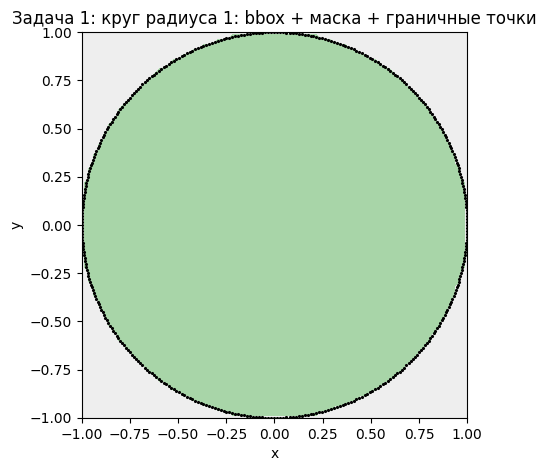

In [ ]:
R = 1.0

domain = {'x': (-R, R), 'y': (-R, R)}
mask_fn_circle = lambda c: (c['x']**2 + c['y']**2) <= R**2

def eq_poisson_circle(u, c, D):
    # -Δu = 1  ⇔  Δu + 1 = 0  ⇔  u_xx + u_yy + 1 = 0
    return D(u, c['x'], 2) + D(u, c['y'], 2) + 1.0

def exact_poisson_circle(x, y):
    return (R**2 - x**2 - y**2) / 4.0

bnd_circle = boundary_circle(R=R, n=400)
conditions = [
    {'type': 'dirichlet', 'custom_coords': bnd_circle, 'value': 0.0},
]

show_geometry(domain, mask_fn_circle, [bnd_circle],
              'Задача 1: круг радиуса 1')


In [6]:
solver = PINNSolver(
    equation=eq_poisson_circle, domain=domain, conditions=conditions,
    domain_mask=mask_fn_circle,
    hidden_size=64, num_hidden_layers=4, activation='tanh',
    loss_weighting='grad_norm', lambda_res=1.0, lambda_cond=10.0,
    device=DEVICE,
)
solver.solve(n_epochs_adam=5000, n_collocation=3000, n_condition=400,
             lr=1e-3, use_lbfgs=True, lbfgs_max_iter=2000);


Adam (5000 ep, lr=0.001, coll=3000 random)


Adam:   0%|          | 0/5000 [00:00<?, ?it/s]c:\Users\NikitoZ\miniconda3\envs\pinn\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Adam:  40%|████      | 2005/5000 [00:41<01:01, 49.06it/s]

   2000 | L=2.73e-05 | res=1.14e-05 | cond=1.36e-06


Adam:  80%|████████  | 4008/5000 [01:21<00:19, 51.05it/s]

   4000 | L=4.77e-06 | res=4.45e-06 | cond=4.98e-07


Adam: 100%|██████████| 5000/5000 [01:41<00:00, 49.35it/s]


L-BFGS (max 2000)
  L-BFGS   200 | L=4.14e-06
  L-BFGS   400 | L=4.12e-06
  L-BFGS   600 | L=4.08e-06
Done 115.7s | res=4.15e-06 | cond=2.77e-07 | total=4.05e-06



=== Задача 1: Пуассон в круге ===
  Bounding box: x∈[-1, 1], y∈[-1, 1]
  Точек внутри Ω (на сетке 160×160): 19856 / 25600
  Ошибка внутри Ω:  Rel L2 = 1.609e-03   max |Δ| = 9.728e-04
  Сохранено: plots\task_01_function.png


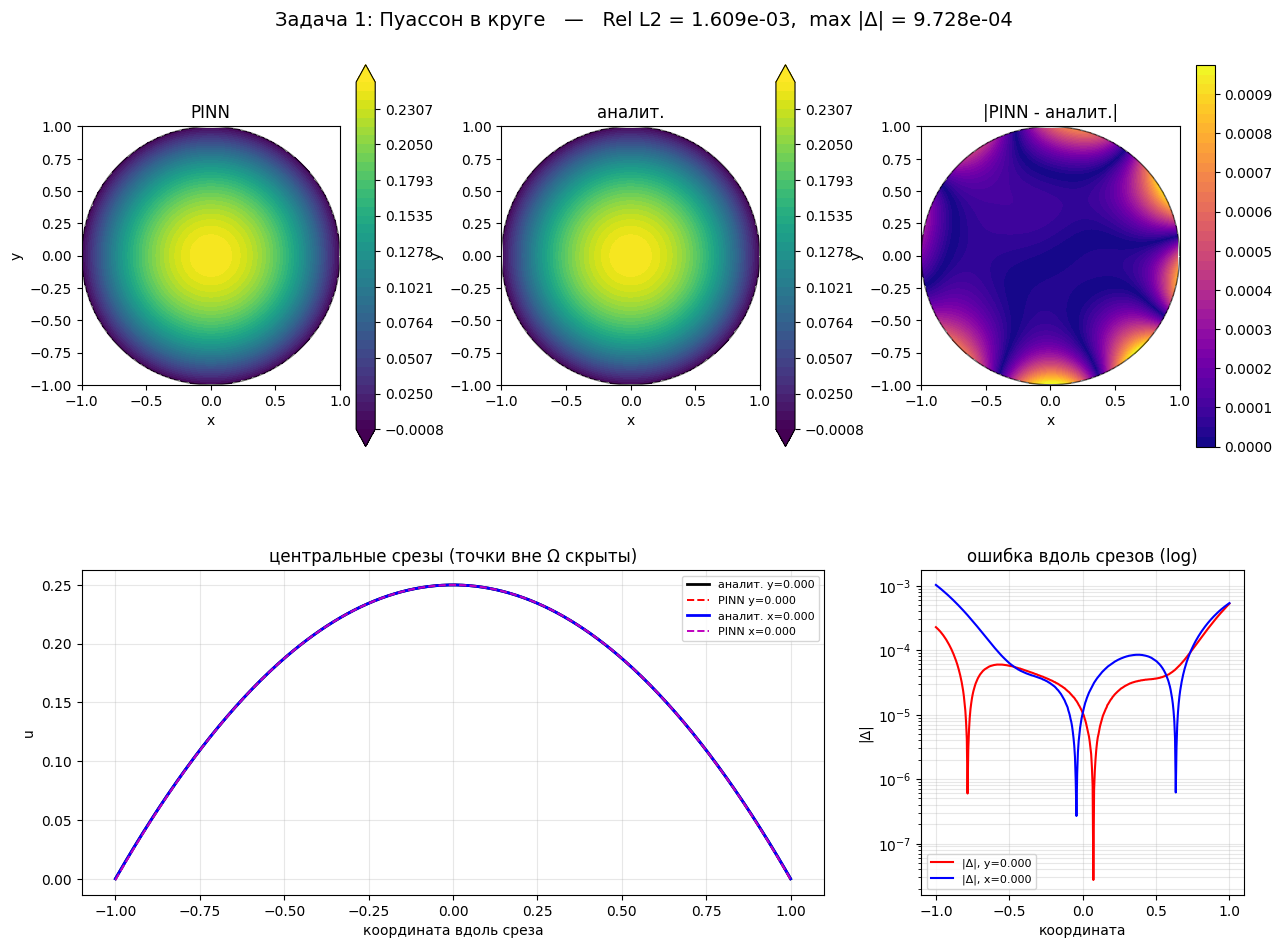

  Сохранено: plots\task_01_diag.png


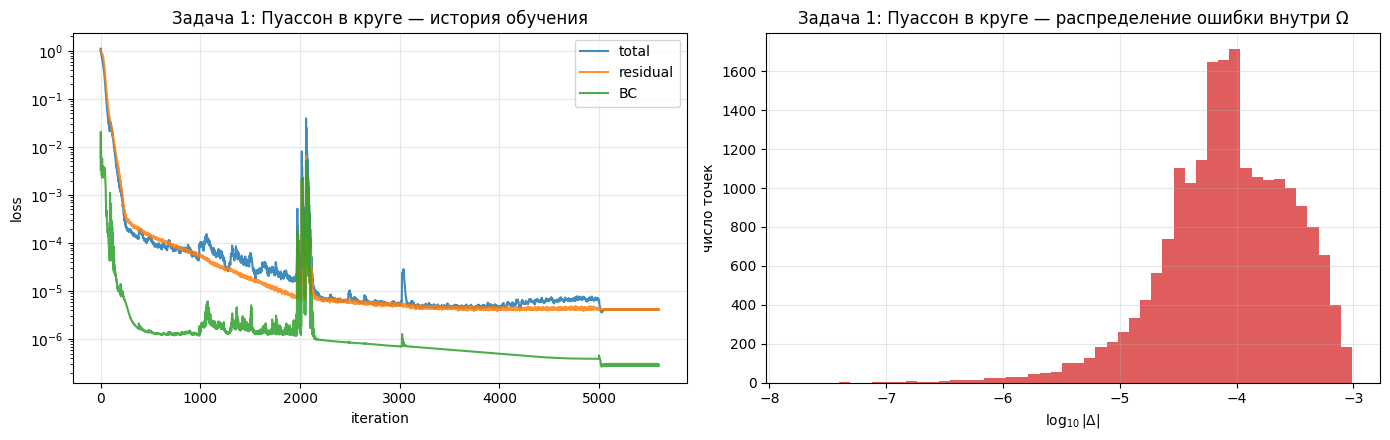

In [7]:
visualize_stationary_2d(
    solver, exact_poisson_circle, domain, mask_fn_circle,
    title='Задача 1: Пуассон в круге',
    filename='task_01',
    boundary_coords=bnd_circle,
);


## 2.
**Область:**
$$\Omega = \left\{(x, y) \in \mathbb{R}^{2} : \dfrac{x^{2}}{a^{2}} + \dfrac{y^{2}}{b^{2}} < 1\right\}, \qquad a = 2,\ b = 1.$$

**Постановка**:
$$
\begin{cases}
\dfrac{\partial^{2}\psi}{\partial x^{2}} + \dfrac{\partial^{2}\psi}{\partial y^{2}} = -2, & (x, y) \in \Omega, \\[2mm]
\psi(x, y) = 0, & (x, y) \in \partial\Omega.
\end{cases}
$$

**Аналитическое решение:**
$$\psi(x, y) = \dfrac{a^{2} b^{2}}{a^{2} + b^{2}}\left(1 - \dfrac{x^{2}}{a^{2}} - \dfrac{y^{2}}{b^{2}}\right).$$

При $a=2$, $b=1$:
$$\psi(x, y) = \dfrac{4}{5} - \dfrac{x^{2}}{5} - \dfrac{4 y^{2}}{5}.$$




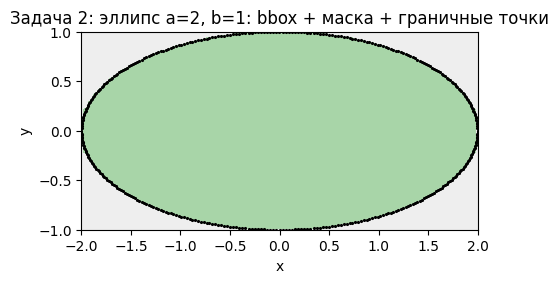

In [ ]:
a_e, b_e = 2.0, 1.0

domain = {'x': (-a_e, a_e), 'y': (-b_e, b_e)}
mask_fn_ellipse = lambda c: (c['x']**2 / a_e**2 + c['y']**2 / b_e**2) <= 1.0

def eq_torsion(u, c, D):
    # u_xx + u_yy + 2 = 0  (т.е. Δu = -2)
    return D(u, c['x'], 2) + D(u, c['y'], 2) + 2.0

coef_T = (a_e**2 * b_e**2) / (a_e**2 + b_e**2)
def exact_torsion(x, y):
    return coef_T * (1.0 - x**2 / a_e**2 - y**2 / b_e**2)

bnd_ellipse = boundary_ellipse(a=a_e, b=b_e, n=400)
conditions = [
    {'type': 'dirichlet', 'custom_coords': bnd_ellipse, 'value': 0.0},
]

show_geometry(domain, mask_fn_ellipse, [bnd_ellipse],
              'Задача 2: эллипс a=2, b=1')


In [9]:
solver = PINNSolver(
    equation=eq_torsion, domain=domain, conditions=conditions,
    domain_mask=mask_fn_ellipse,
    hidden_size=64, num_hidden_layers=4, activation='tanh',
    loss_weighting='grad_norm', lambda_res=1.0, lambda_cond=10.0,
    device=DEVICE,
)
solver.solve(n_epochs_adam=5000, n_collocation=3000, n_condition=400,
             lr=1e-3, use_lbfgs=True, lbfgs_max_iter=2000);


Adam (5000 ep, lr=0.001, coll=3000 random)


Adam:  40%|████      | 2004/5000 [00:39<00:57, 51.83it/s]

   2000 | L=2.10e-05 | res=2.19e-05 | cond=1.30e-06


Adam:  80%|████████  | 4008/5000 [01:17<00:18, 52.28it/s]

   4000 | L=5.97e-06 | res=7.94e-06 | cond=2.08e-07


Adam: 100%|██████████| 5000/5000 [01:36<00:00, 51.78it/s]


L-BFGS (max 2000)
  L-BFGS   200 | L=4.65e-06
  L-BFGS   400 | L=4.62e-06
  L-BFGS   600 | L=4.58e-06
Done 111.1s | res=6.73e-06 | cond=6.32e-08 | total=4.58e-06



=== Задача 2: кручение эллиптического бруса ===
  Bounding box: x∈[-2, 2], y∈[-1, 1]
  Точек внутри Ω (на сетке 160×160): 19856 / 25600
  Ошибка внутри Ω:  Rel L2 = 2.741e-04   max |Δ| = 5.988e-04
  Сохранено: plots\task_02_function.png


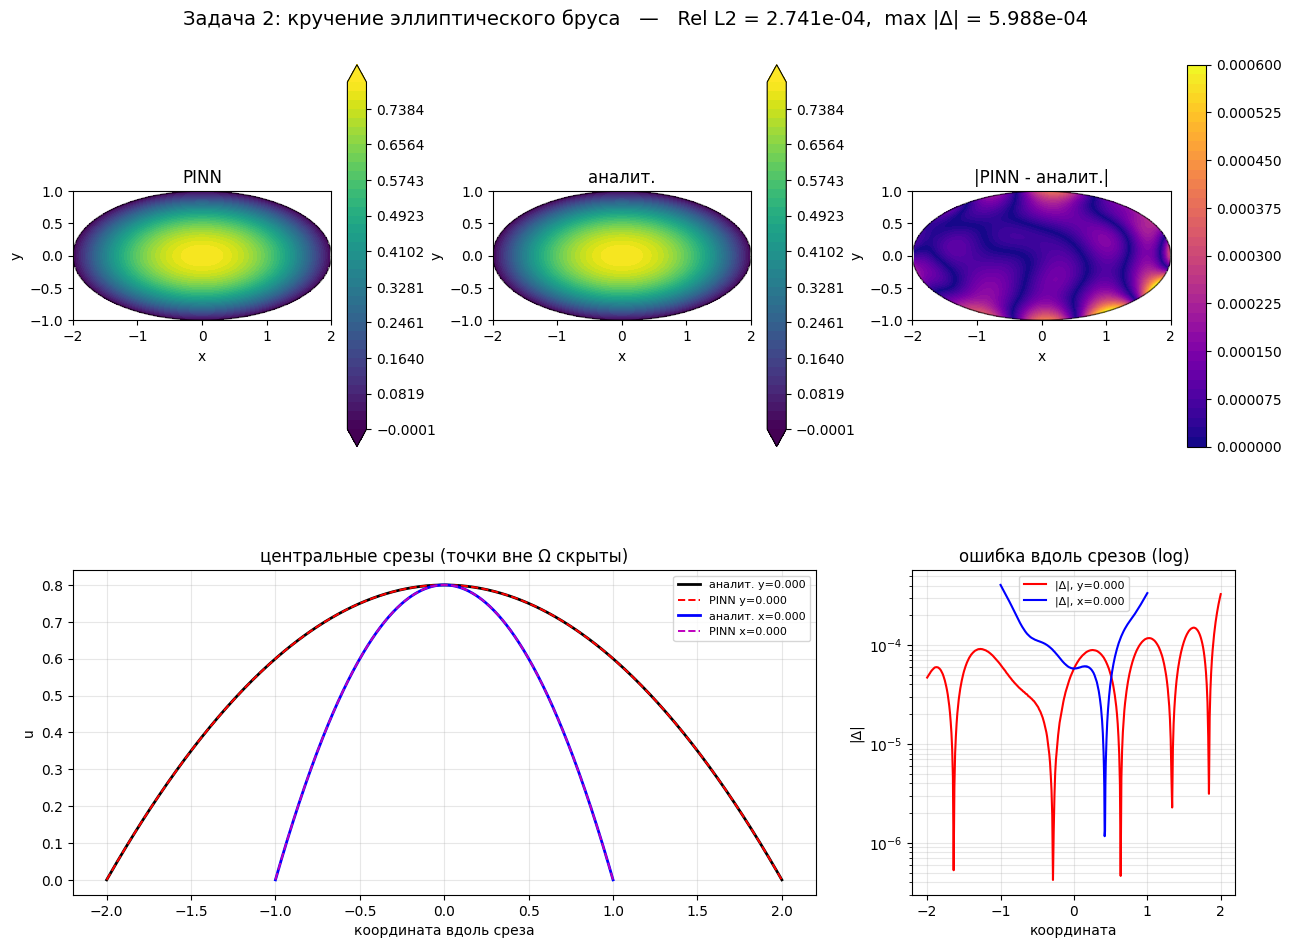

  Сохранено: plots\task_02_diag.png


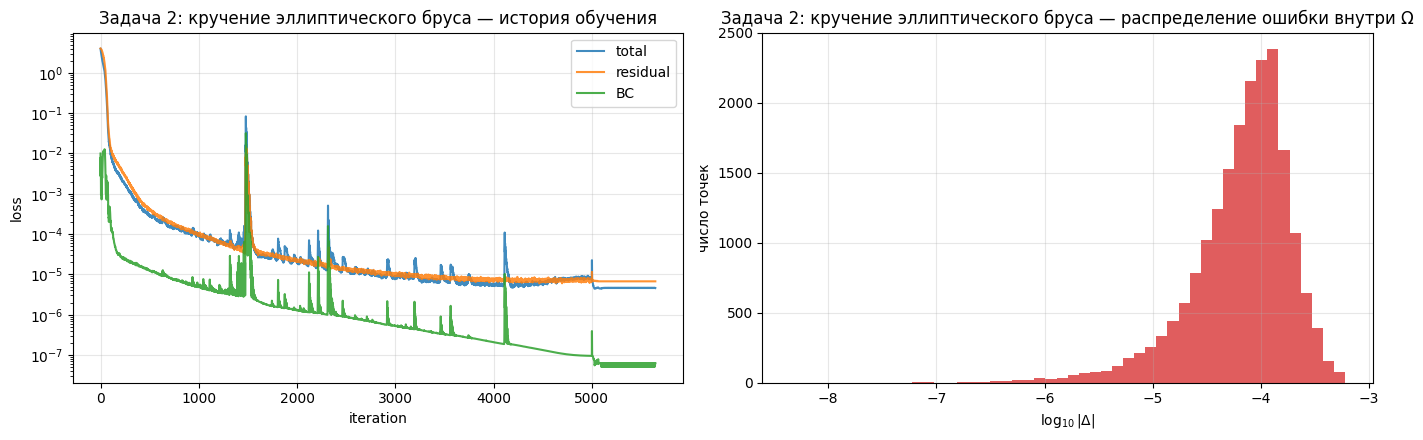

In [10]:
visualize_stationary_2d(
    solver, exact_torsion, domain, mask_fn_ellipse,
    title='Задача 2: кручение эллиптического бруса',
    filename='task_02',
    boundary_coords=bnd_ellipse,
);


## 3.

**Область:**
$$\Omega = \{(x, y) \in \mathbb{R}^{2} : R_{1}^{2} < x^{2} + y^{2} < R_{2}^{2}\}, \qquad R_{1} = 1,\ R_{2} = 2.$$

**Постановка:**
$$
\begin{cases}
\dfrac{\partial^{2} u}{\partial x^{2}} + \dfrac{\partial^{2} u}{\partial y^{2}} = 0, & (x, y) \in \Omega, \\[2mm]
u(x, y) = 0, & x^{2} + y^{2} = R_{1}^{2}, \\[2mm]
u(x, y) = 1, & x^{2} + y^{2} = R_{2}^{2}.
\end{cases}
$$

**Аналитическое решение:**
$$U(x, y) = \dfrac{\ln\sqrt{x^{2}+y^{2}}}{\ln(R_{2}/R_{1})} = \dfrac{\ln(x^{2}+y^{2})}{2\ln 2}.$$


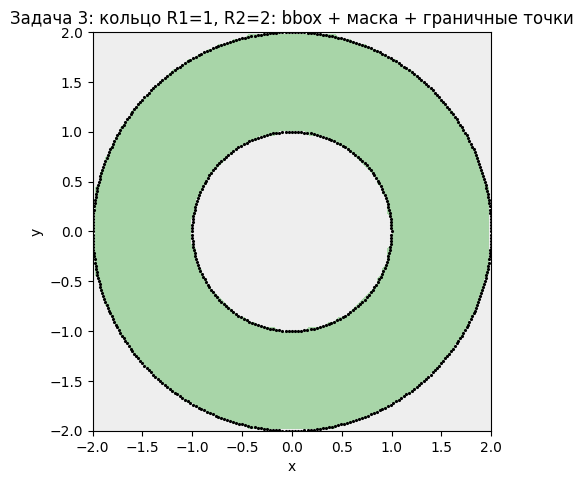

In [ ]:
R1, R2 = 1.0, 2.0

domain = {'x': (-R2, R2), 'y': (-R2, R2)}

def mask_fn_annulus(c):
    r2 = c['x']**2 + c['y']**2
    return (r2 >= R1**2) & (r2 <= R2**2)

def eq_laplace(u, c, D):
    return D(u, c['x'], 2) + D(u, c['y'], 2)

def exact_annulus(x, y):
    return np.log(np.sqrt(x**2 + y**2)) / np.log(R2 / R1)

bnd_inner, bnd_outer = boundary_annulus(R1=R1, R2=R2,
                                         n_inner=200, n_outer=400)
conditions = [
    {'type': 'dirichlet', 'custom_coords': bnd_inner, 'value': 0.0},
    {'type': 'dirichlet', 'custom_coords': bnd_outer, 'value': 1.0},
]

show_geometry(domain, mask_fn_annulus, [bnd_inner, bnd_outer],
              'Задача 3: кольцо R1=1, R2=2')


In [12]:
solver = PINNSolver(
    equation=eq_laplace, domain=domain, conditions=conditions,
    domain_mask=mask_fn_annulus,
    hidden_size=64, num_hidden_layers=4, activation='tanh',
    loss_weighting='grad_norm', lambda_res=1.0, lambda_cond=10.0,
    device=DEVICE,
)
solver.solve(n_epochs_adam=6000, n_collocation=4000, n_condition=300,
             lr=1e-3, use_lbfgs=True, lbfgs_max_iter=2500);


Adam (6000 ep, lr=0.001, coll=4000 random)


Adam:  33%|███▎      | 2008/6000 [00:44<01:27, 45.50it/s]

   2000 | L=3.49e-04 | res=1.30e-04 | cond=2.64e-05


Adam:  67%|██████▋   | 4004/6000 [01:31<00:47, 42.36it/s]

   4000 | L=1.43e-04 | res=5.08e-05 | cond=8.09e-06


Adam: 100%|██████████| 6000/6000 [02:19<00:00, 43.14it/s]


   6000 | L=4.24e-05 | res=5.40e-05 | cond=2.21e-06
L-BFGS (max 2500)
  L-BFGS   200 | L=5.81e-05
  L-BFGS   400 | L=5.81e-05
  L-BFGS   600 | L=5.81e-05
Done 155.1s | res=5.23e-05 | cond=2.21e-06 | total=5.64e-05



=== Задача 3: Лаплас в кольце ===
  Bounding box: x∈[-2, 2], y∈[-2, 2]
  Точек внутри Ω (на сетке 160×160): 14888 / 25600
  Ошибка внутри Ω:  Rel L2 = 8.329e-04   max |Δ| = 2.728e-03
  Сохранено: plots\task_03_function.png


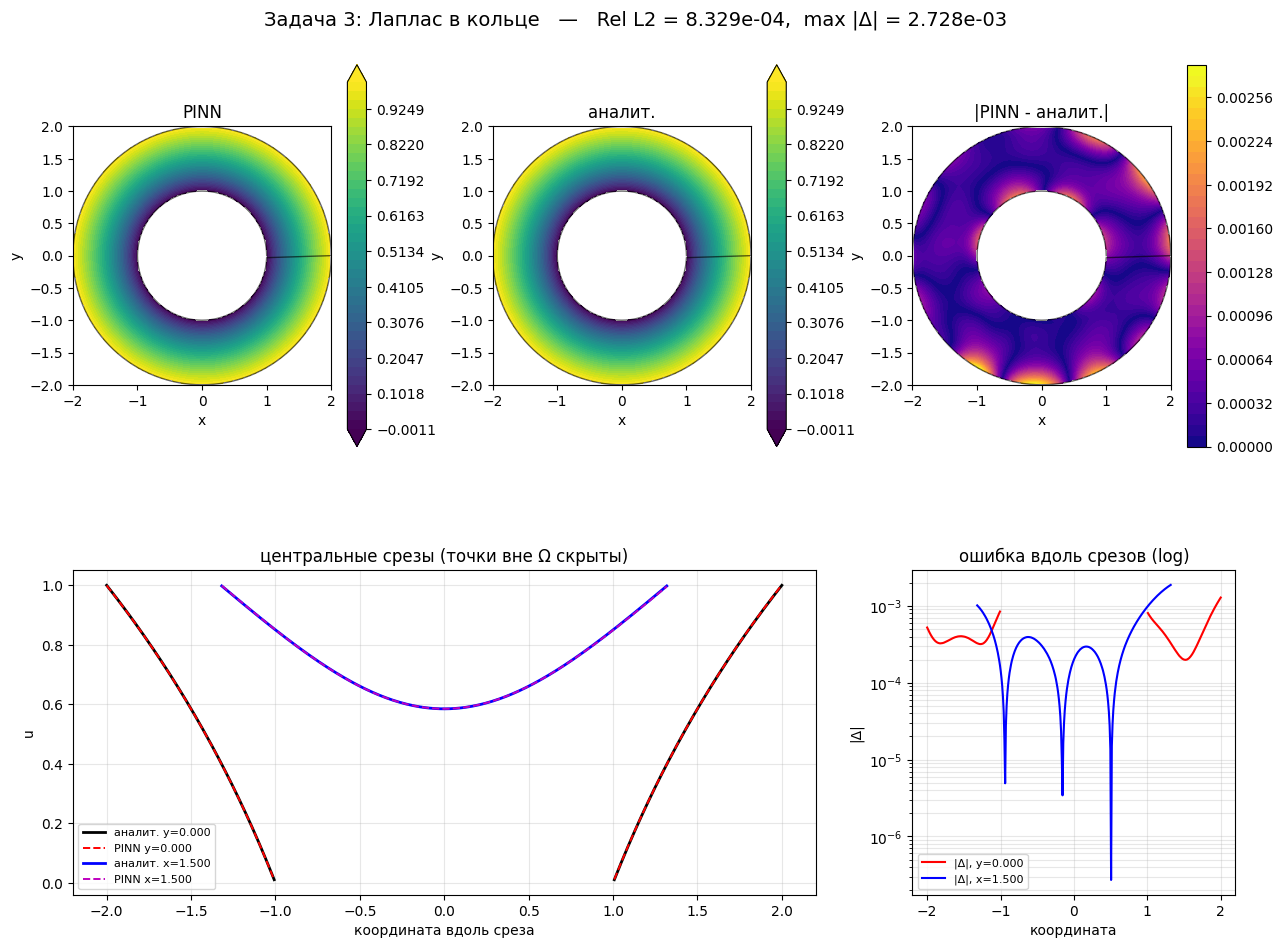

  Сохранено: plots\task_03_diag.png


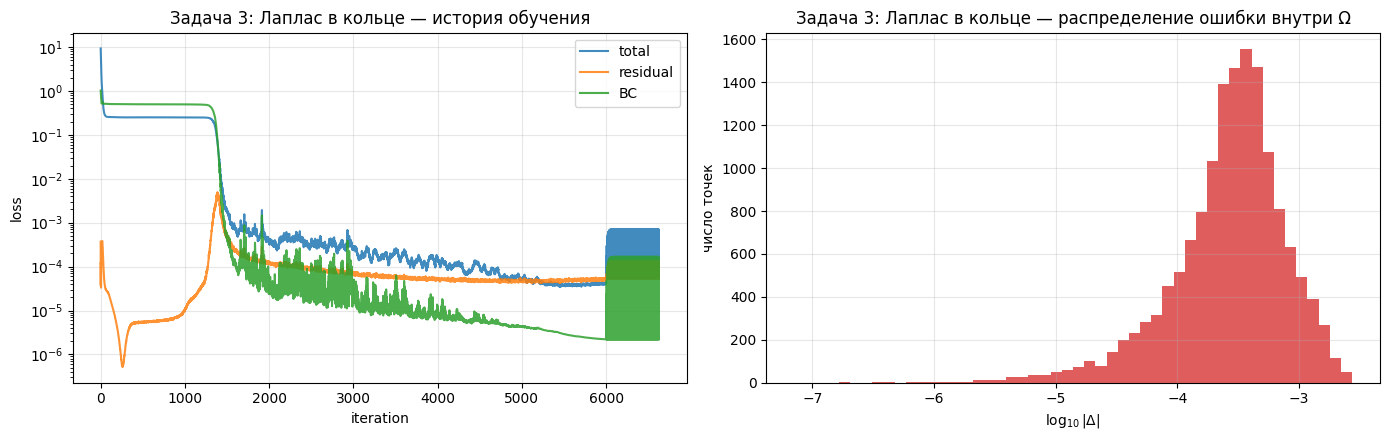

In [ ]:
visualize_stationary_2d(
    solver, exact_annulus, domain, mask_fn_annulus,
    title='Задача 3: Лаплас в кольце',
    filename='task_03',
    boundary_coords={'x': np.concatenate([bnd_inner['x'], bnd_outer['x']]),
                     'y': np.concatenate([bnd_inner['y'], bnd_outer['y']])},
    x_slice=1.5, y_slice=0.0,
);


## 4.

**Область**:
$$\Omega = (-1, 1) \times (-1, 1)\ \setminus\ [\,0, 1\,] \times [\,-1, 0\,].$$

**Постановка:**
$$
\begin{cases}
\dfrac{\partial^{2} u}{\partial x^{2}} + \dfrac{\partial^{2} u}{\partial y^{2}} = 0, & (x, y) \in \Omega, \\[2mm]
u(x, y) = g(x, y), & (x, y) \in \partial\Omega,
\end{cases}
$$

**Аналитическое решение:**
$$U(x, y) = x^{2} - y^{2}.$$


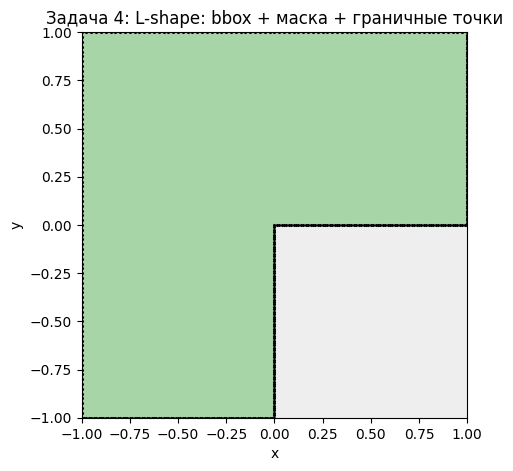

In [ ]:
domain = {'x': (-1.0, 1.0), 'y': (-1.0, 1.0)}

def mask_fn_lshape(c):
    return ~((c['x'] >= 0.0) & (c['y'] <= 0.0))

def eq_laplace_L(u, c, D):
    return D(u, c['x'], 2) + D(u, c['y'], 2)

def exact_L(x, y):
    return x**2 - y**2

bnd_L = boundary_lshape(n_per=80)

def g_L(coords):
    return coords['x']**2 - coords['y']**2

conditions = [
    {'type': 'dirichlet', 'custom_coords': bnd_L, 'value': g_L},
]

show_geometry(domain, mask_fn_lshape, [bnd_L],
              'Задача 4: L-shape')


In [15]:
solver = PINNSolver(
    equation=eq_laplace_L, domain=domain, conditions=conditions,
    domain_mask=mask_fn_lshape,
    hidden_size=80, num_hidden_layers=5, activation='tanh',
    loss_weighting='grad_norm', lambda_res=1.0, lambda_cond=10.0,
    device=DEVICE,
)
solver.solve(n_epochs_adam=6000, n_collocation=4000, n_condition=400,
             lr=1e-3, use_lbfgs=True, lbfgs_max_iter=2500);


Adam (6000 ep, lr=0.001, coll=4000 random)


Adam:  33%|███▎      | 2007/6000 [00:49<01:37, 40.88it/s]

   2000 | L=1.22e-05 | res=1.10e-05 | cond=1.43e-06


Adam:  67%|██████▋   | 4003/6000 [01:36<00:51, 38.99it/s]

   4000 | L=4.53e-06 | res=5.30e-06 | cond=4.24e-07


Adam: 100%|██████████| 6000/6000 [02:22<00:00, 42.13it/s]


   6000 | L=6.43e-06 | res=5.28e-06 | cond=1.76e-07
L-BFGS (max 2500)
  L-BFGS   200 | L=4.70e-06
  L-BFGS   400 | L=4.70e-06
  L-BFGS   600 | L=4.70e-06
Done 162.5s | res=6.43e-06 | cond=1.18e-07 | total=4.62e-06



=== Задача 4: Лаплас на L-shape (гладкое реш.) ===
  Bounding box: x∈[-1, 1], y∈[-1, 1]
  Точек внутри Ω (на сетке 160×160): 19200 / 25600
  Ошибка внутри Ω:  Rel L2 = 4.013e-04   max |Δ| = 1.185e-03
  Сохранено: plots\task_04_function.png


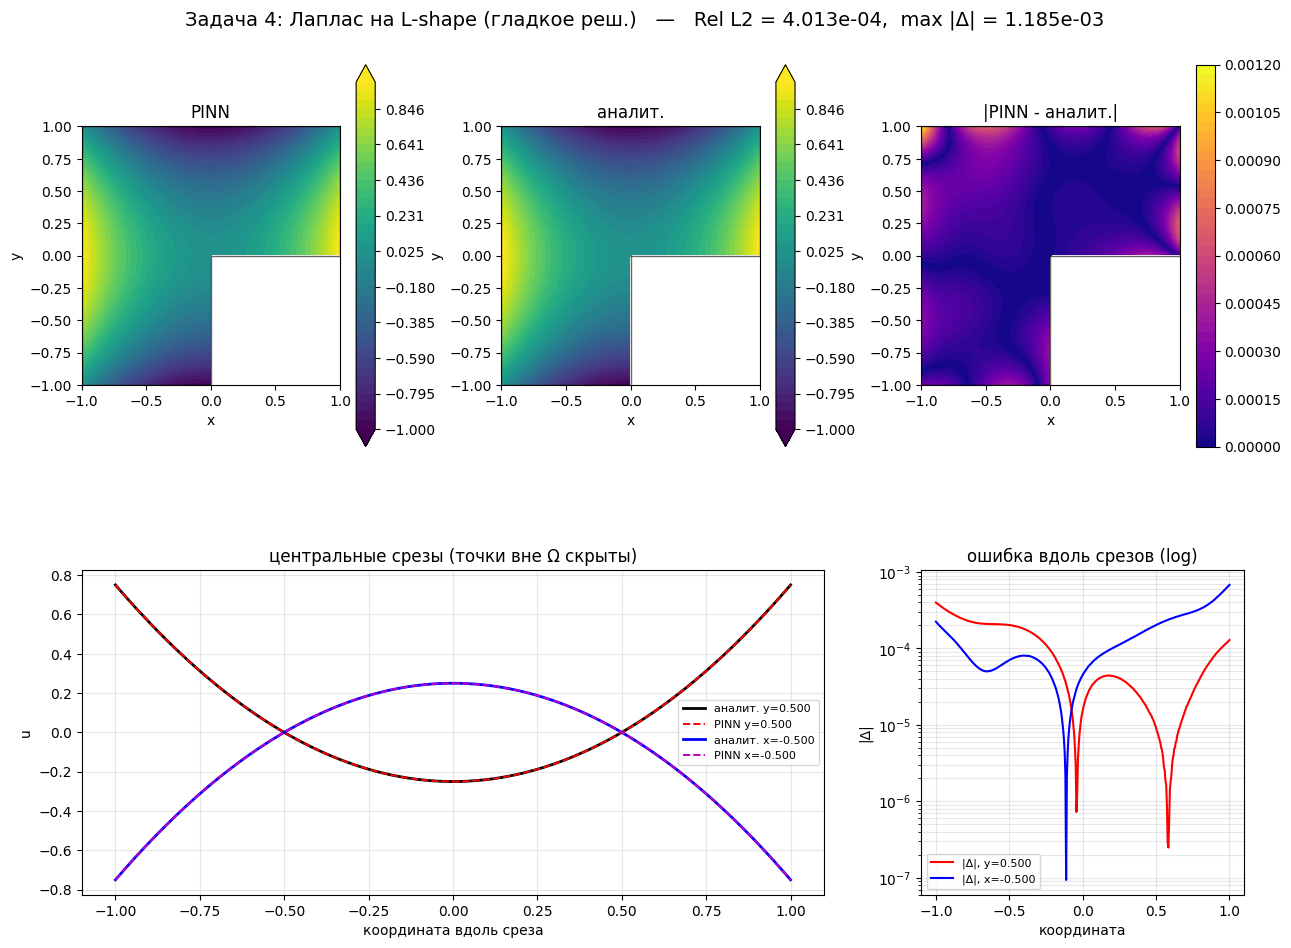

  Сохранено: plots\task_04_diag.png


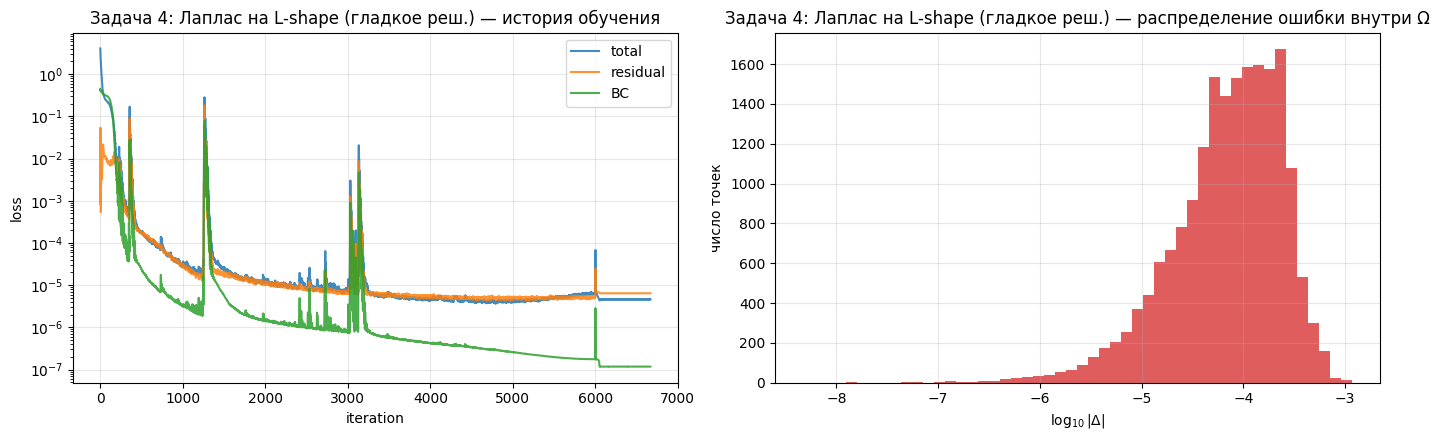

In [ ]:
visualize_stationary_2d(
    solver, exact_L, domain, mask_fn_lshape,
    title='Задача 4: Лаплас на L-shape (гладкое реш.)',
    filename='task_04',
    boundary_coords=bnd_L,
    x_slice=-0.5, y_slice=0.5,
);
